# Translation Quality Comparison Report

This notebook compares the evaluated quality of two or more translations of the same source text.
Each translation is a separate Label Studio JSON export annotated independently by evaluators.

**What this report produces:**
- Executive summary table with key metrics per translation
- Side-by-side correspondence and readability ratings
- Side-by-side error volume and distribution
- Condensed IAA reliability table (span F1 and Cohen's Kappa) to contextualize the comparison
- Qualitative evaluator comments for each translation

## 1. Project Config

Edit this cell for each new comparison run.

- `TRANSLATIONS` — list of conditions to compare. Each entry needs:
  - `label`: display name used in all charts, tables, and the report filename
  - `file`: path to the Label Studio JSON export for this translation
  - `color`: hex color used consistently for this condition across all charts
- `PROJECT_NAME` — used in the report title
- `REPORT_DATE` — date label for this round (YYYY-MM-DD)
- `OUTPUT_DIR` — where the HTML report will be written

In [11]:
# ── PROJECT CONFIG ────────────────────────────────────────────────────────────

PROJECT_NAME  = "TQE-2026-1-Project6-Compare"
REPORT_DATE   = "2026-06-10"   # update each round
OUTPUT_DIR    = "./reports"

TRANSLATIONS = [
    {
        "label": "Translation A",
        "file":  "./data/WhatAI-IsNot_esp-MEX_1_parsed.json",
        "color": "#4C72B0",
    },
    {
        "label": "Translation B",
        "file":  "./data/WhatAI-IsNot_esp-MEX_2_parsed.json",
        "color": "#DD8452",
    },
    # Add more conditions here as needed:
    # {
    #     "label": "Translation C",
    #     "file":  "./data/translation_c.json",
    #     "color": "#55A868",
    # },
]

## 2. Imports

In [12]:
import json
import os
import datetime
import io
import base64
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print(f"pandas     {pd.__version__}")
print(f"numpy      {np.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"seaborn    {sns.__version__}")

plt.style.use('ggplot')

pandas     2.2.3
numpy      2.2.6
matplotlib 3.10.0
seaborn    0.13.2


## 3. Data Loading and Parsing

Reuses the same Label Studio parsing logic as the individual IAA notebook.
Each translation is loaded into its own `task_id_to_annotations` dict,
then stored in `conditions` — a list of dicts keyed by the label from config.

In [13]:
def parse_result_array(result):
    """
    Flatten a Label Studio annotation's result array into a structured dict.
    Span items share a region ID — grouped before building enriched_labels.
    Document-level fields collected separately. Relation items skipped.
    """
    regions = {}

    doc_fields = {
        "overall_correspondence":  None,
        "overall_readability":     None,
        "document_issues":         None,
        "correspondence_comments": None,
        "readability_comments":    None,
    }

    for item in result:
        from_name = item.get("from_name")
        if from_name is None:
            continue

        value     = item.get("value", {})
        region_id = item.get("id")

        if from_name == "label":
            if region_id not in regions:
                regions[region_id] = {
                    "start": value.get("start"),
                    "end":   value.get("end"),
                    "text":  value.get("text", ""),
                }
            regions[region_id]["labels"] = value.get("labels", [])

        elif from_name == "impact":
            if region_id not in regions:
                regions[region_id] = {}
            choices = value.get("choices", [])
            regions[region_id]["impact"] = choices[0] if choices else None

        elif from_name == "subcategories":
            if region_id not in regions:
                regions[region_id] = {}
            choices = value.get("choices", [])
            regions[region_id]["subcategory"] = choices[0] if choices else None

        elif from_name == "comments":
            if region_id not in regions:
                regions[region_id] = {}
            texts = value.get("text", [])
            regions[region_id]["comments"] = texts[0] if texts else None

        elif from_name == "overall_correspondence":
            doc_fields["overall_correspondence"] = value.get("rating")

        elif from_name == "overall_readability":
            doc_fields["overall_readability"] = value.get("rating")

        elif from_name in ("document_issues", "correspondence_comments", "readability_comments"):
            texts = value.get("text", [])
            doc_fields[from_name] = texts[0] if texts else None

    enriched_labels = []
    for region_id, region in regions.items():
        if "labels" not in region:
            continue
        enriched_labels.append({
            "start":       region.get("start"),
            "end":         region.get("end"),
            "text":        region.get("text", ""),
            "labels":      region.get("labels", []),
            "subcategory": region.get("subcategory"),
            "impact":      region.get("impact"),
            "comments":    region.get("comments"),
        })

    return {"enriched_labels": enriched_labels, **doc_fields}


def parse_label_studio_export(file_path):
    """
    Load a single Label Studio JSON export and return task_id_to_annotations dict.
    """
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    print(f"  Reading: {os.path.basename(file_path)}")
    with open(file_path, "r", encoding="utf-8") as f:
        tasks = json.load(f)
    print(f"  {len(tasks)} task(s)")

    task_id_to_annotations = {}

    for task in tasks:
        task_id = task["id"]
        text    = task["data"]["text"]

        if task_id not in task_id_to_annotations:
            task_id_to_annotations[task_id] = []

        for raw_ann in task.get("annotations", []):
            if raw_ann.get("was_cancelled"):
                continue

            parsed = parse_result_array(raw_ann.get("result", []))

            review_time_seconds = None
            try:
                created = datetime.datetime.fromisoformat(
                    raw_ann["created_at"].replace("Z", "+00:00"))
                updated = datetime.datetime.fromisoformat(
                    raw_ann["updated_at"].replace("Z", "+00:00"))
                review_time_seconds = (updated - created).total_seconds()
            except (KeyError, ValueError, TypeError):
                pass

            annotation = {
                "task_id":             task_id,
                "annotation_id":       raw_ann["id"],
                "annotator_id":        raw_ann["completed_by"],
                "text":                text,
                "lead_time":           raw_ann.get("lead_time"),
                "lead_time_minutes":   round(raw_ann.get("lead_time", 0) / 60, 2),
                "created_at":          raw_ann.get("created_at"),
                "updated_at":          raw_ann.get("updated_at"),
                "review_time":         review_time_seconds,
                "review_time_minutes": (
                    round(review_time_seconds / 60, 2)
                    if review_time_seconds is not None else None
                ),
                **parsed,
            }
            task_id_to_annotations[task_id].append(annotation)

    return task_id_to_annotations

In [14]:
# Load all conditions
conditions = []

for cfg in TRANSLATIONS:
    print(f"\nLoading: {cfg['label']}")
    data = parse_label_studio_export(cfg["file"])
    total_annotations = sum(len(v) for v in data.values())
    total_spans       = sum(len(a['enriched_labels']) for anns in data.values() for a in anns)
    print(f"  Tasks: {len(data)} | Annotations: {total_annotations} | Spans: {total_spans}")
    conditions.append({
        "label": cfg["label"],
        "color": cfg["color"],
        "data":  data,
    })

print(f"\n{'='*50}")
print(f"Conditions loaded: {len(conditions)}")
for c in conditions:
    n_ann = sum(len(v) for v in c['data'].values())
    print(f"  {c['label']}: {n_ann} annotation(s)")


Loading: Translation A
  Reading: WhatAI-IsNot_esp-MEX_1_parsed.json
  1 task(s)
  Tasks: 1 | Annotations: 2 | Spans: 51

Loading: Translation B
  Reading: WhatAI-IsNot_esp-MEX_2_parsed.json
  1 task(s)
  Tasks: 1 | Annotations: 2 | Spans: 31

Conditions loaded: 2
  Translation A: 2 annotation(s)
  Translation B: 2 annotation(s)


## 4. Analysis Functions

Helper functions that compute per-condition metrics.
All functions take a `task_id_to_annotations` dict and return structured results.

In [15]:
def get_ratings(task_id_to_annotations):
    """
    Extract correspondence and readability ratings from all annotations.
    Returns lists of numeric values (None entries skipped).
    """
    corr, read = [], []
    for anns in task_id_to_annotations.values():
        for a in anns:
            if a.get("overall_correspondence") is not None:
                corr.append(a["overall_correspondence"])
            if a.get("overall_readability") is not None:
                read.append(a["overall_readability"])
    return corr, read


def get_error_counts(task_id_to_annotations):
    """
    Count total spans and break down by error category and impact.
    Returns (total_spans, category_counts_dict, impact_counts_dict).
    """
    from collections import Counter
    cat_counter    = Counter()
    impact_counter = Counter()
    total = 0

    for anns in task_id_to_annotations.values():
        for a in anns:
            for span in a.get("enriched_labels", []):
                total += 1
                for lbl in span.get("labels", []):
                    cat_counter[lbl] += 1
                impact = span.get("impact")
                if impact:
                    impact_counter[impact] += 1

    return total, dict(cat_counter), dict(impact_counter)


def calculate_span_f1(task_id_to_annotations):
    """
    Calculate average span F1 across all annotator pairs.
    Returns overall avg_f1 (float) or None if fewer than 2 annotators.
    """
    all_f1s = []

    for anns in task_id_to_annotations.values():
        annotator_to_spans = {}
        for a in anns:
            aid = a.get("annotator_id")
            if not aid:
                continue
            annotator_to_spans[aid] = [
                {"start": lbl["start"], "end": lbl["end"]}
                for lbl in a.get("enriched_labels", [])
            ]

        if len(annotator_to_spans) < 2:
            continue

        for a1, a2 in combinations(annotator_to_spans.keys(), 2):
            spans1 = annotator_to_spans[a1]
            spans2 = annotator_to_spans[a2]
            if not spans1 or not spans2:
                continue

            max_pos = max(s["end"] for s in spans1 + spans2)
            arr1 = np.zeros(max_pos + 1, dtype=bool)
            arr2 = np.zeros(max_pos + 1, dtype=bool)
            for s in spans1:
                arr1[s["start"]:s["end"]] = True
            for s in spans2:
                arr2[s["start"]:s["end"]] = True

            tp  = np.sum(arr1 & arr2)
            p   = tp / np.sum(arr1) if np.sum(arr1) > 0 else 0
            r   = tp / np.sum(arr2) if np.sum(arr2) > 0 else 0
            f1  = 2 * p * r / (p + r) if (p + r) > 0 else 0
            all_f1s.append(f1)

    return float(np.mean(all_f1s)) if all_f1s else None


def calculate_mean_kappa(task_id_to_annotations):
    """
    Calculate mean Cohen's Kappa for error category agreement across annotator pairs.
    Returns mean kappa (float) or None if insufficient data.
    """
    all_kappas  = []
    all_weights = []

    for anns in task_id_to_annotations.values():
        annotator_to_spans = {}
        for a in anns:
            aid = a.get("annotator_id")
            if not aid:
                continue
            annotator_to_spans[aid] = [
                {
                    "start":    lbl["start"],
                    "end":      lbl["end"],
                    "category": lbl["labels"][0] if lbl.get("labels") else "",
                }
                for lbl in a.get("enriched_labels", [])
            ]

        if len(annotator_to_spans) < 2:
            continue

        for a1, a2 in combinations(annotator_to_spans.keys(), 2):
            spans1 = annotator_to_spans[a1]
            spans2 = annotator_to_spans[a2]
            if not spans1 or not spans2:
                continue

            overlapping = []
            for s1 in spans1:
                for s2 in spans2:
                    if s1["start"] < s2["end"] and s2["start"] < s1["end"]:
                        olen = min(s1["end"], s2["end"]) - max(s1["start"], s2["start"])
                        mlen = min(s1["end"] - s1["start"], s2["end"] - s2["start"])
                        if mlen > 0 and olen / mlen >= 0.5:
                            overlapping.append((s1["category"], s2["category"]))

            if len(overlapping) < 2:
                continue

            cats1 = [o[0] for o in overlapping]
            cats2 = [o[1] for o in overlapping]
            try:
                k = cohen_kappa_score(cats1, cats2)
                all_kappas.append(k)
                all_weights.append(len(overlapping))
            except Exception:
                pass

    if not all_kappas:
        return None
    total_w = sum(all_weights)
    return sum(k * w for k, w in zip(all_kappas, all_weights)) / total_w


def kappa_label(k):
    if k is None:
        return "N/A"
    if k > 0.80: return "Almost perfect"
    if k > 0.60: return "Substantial"
    if k > 0.40: return "Moderate"
    if k > 0.20: return "Fair"
    return "Poor"


def get_qualitative_comments(task_id_to_annotations):
    """
    Extract all document-level free-text comments from annotations.
    Returns list of dicts with annotator_id and comment fields.
    """
    comments = []
    for anns in task_id_to_annotations.values():
        for a in anns:
            entry = {"annotator_id": a["annotator_id"]}
            entry["document_issues"]         = a.get("document_issues")
            entry["correspondence_comments"] = a.get("correspondence_comments")
            entry["readability_comments"]    = a.get("readability_comments")
            if any(v for v in entry.values() if isinstance(v, str) and v.strip()):
                comments.append(entry)
    return comments

In [16]:
# Compute all metrics for every condition
for c in conditions:
    data = c["data"]
    corr, read                    = get_ratings(data)
    total_spans, cat_counts, imp_counts = get_error_counts(data)
    avg_f1                        = calculate_span_f1(data)
    mean_kappa                    = calculate_mean_kappa(data)
    qual_comments                 = get_qualitative_comments(data)

    c["corr_ratings"]   = corr
    c["read_ratings"]   = read
    c["total_spans"]    = total_spans
    c["cat_counts"]     = cat_counts
    c["imp_counts"]     = imp_counts
    c["avg_f1"]         = avg_f1
    c["mean_kappa"]     = mean_kappa
    c["qual_comments"]  = qual_comments
    c["n_annotators"]   = len(set(
        a["annotator_id"]
        for anns in data.values() for a in anns
    ))

    f1_str    = f"{avg_f1:.3f}" if avg_f1 is not None else "N/A"
    kappa_str = f"{mean_kappa:.3f}" if mean_kappa is not None else "N/A"
    print(f"{c['label']}: corr={[round(x,1) for x in corr]} | read={[round(x,1) for x in read]} | "
        f"spans={total_spans} | F1={f1_str} | kappa={kappa_str}")

Translation A: corr=[2, 3] | read=[3, 2] | spans=51 | F1=0.614 | kappa=0.654
Translation B: corr=[3, 3] | read=[3, 3] | spans=31 | F1=0.530 | kappa=0.737


## 5. Visualizations

Functions for side-by-side charts. Each returns a matplotlib Figure.

In [17]:
def fig_to_html(fig):
    """Encode a matplotlib figure to an inline base64 PNG img tag."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    encoded = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return f'<img src="data:image/png;base64,{encoded}" style="max-width:100%;" />'


def chart_ratings_comparison(conditions):
    """
    Side-by-side grouped bar chart: mean correspondence and readability per condition.
    """
    labels     = [c["label"] for c in conditions]
    corr_means = [np.mean(c["corr_ratings"]) if c["corr_ratings"] else 0 for c in conditions]
    read_means = [np.mean(c["read_ratings"]) if c["read_ratings"] else 0 for c in conditions]

    x     = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(7, len(conditions) * 2.5), 5))
    bars1 = ax.bar(x - width/2, corr_means, width, label="Correspondence",
                   color=[c["color"] for c in conditions], alpha=0.85)
    bars2 = ax.bar(x + width/2, read_means, width, label="Readability",
                   color=[c["color"] for c in conditions], alpha=0.45,
                   edgecolor=[c["color"] for c in conditions], linewidth=1.5)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 5.2)
    ax.set_ylabel("Mean rating (1–4 scale)")
    ax.set_title("Mean Correspondence & Readability Ratings by Translation")
    ax.legend()
    ax.axhline(y=4, color="gray", linestyle=":", alpha=0.5)
    ax.axhline(y=1, color="gray", linestyle=":", alpha=0.5)
    fig.tight_layout()
    return fig


def chart_rating_distributions(conditions):
    """
    One subplot per condition showing rating distribution histograms (correspondence + readability).
    """
    n     = len(conditions)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    bins = [0.5, 1.5, 2.5, 3.5, 4.5]

    for ax, c in zip(axes, conditions):
        corr = c["corr_ratings"]
        read = c["read_ratings"]
        ax.hist(corr, bins=bins, alpha=0.7, label="Correspondence",
                color=c["color"])
        ax.hist(read, bins=bins, alpha=0.4, label="Readability",
                color=c["color"], edgecolor=c["color"], linewidth=1.5)
        ax.set_title(c["label"])
        ax.set_xlabel("Rating (1–4)")
        ax.set_xticks([1, 2, 3, 4])
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Count")
    fig.suptitle("Rating Distributions by Translation", fontsize=13)
    fig.tight_layout()
    return fig


def chart_error_categories(conditions):
    """
    Grouped bar chart comparing error category counts across conditions.
    """
    # Collect all unique categories across conditions
    all_cats = sorted(set(
        cat for c in conditions for cat in c["cat_counts"].keys()
    ))

    n_conditions = len(conditions)
    n_cats       = len(all_cats)
    x            = np.arange(n_cats)
    width        = 0.8 / n_conditions

    fig, ax = plt.subplots(figsize=(max(9, n_cats * 2), 5))

    for i, c in enumerate(conditions):
        counts = [c["cat_counts"].get(cat, 0) for cat in all_cats]
        offset = (i - n_conditions / 2 + 0.5) * width
        bars   = ax.bar(x + offset, counts, width, label=c["label"],
                        color=c["color"], alpha=0.85)
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                        str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(all_cats, rotation=30, ha="right")
    ax.set_ylabel("Span count")
    ax.set_title("Error Category Distribution by Translation")
    ax.legend()
    fig.tight_layout()
    return fig


def chart_error_impact(conditions):
    """
    Grouped bar chart comparing impact level counts across conditions.
    """
    impact_order = ["Strong", "Moderate", "Neutral"]
    all_impacts  = impact_order + sorted(
        set(imp for c in conditions for imp in c["imp_counts"].keys())
        - set(impact_order)
    )

    n_conditions = len(conditions)
    x            = np.arange(len(all_impacts))
    width        = 0.8 / n_conditions

    fig, ax = plt.subplots(figsize=(max(7, len(all_impacts) * 2), 5))

    for i, c in enumerate(conditions):
        counts = [c["imp_counts"].get(imp, 0) for imp in all_impacts]
        offset = (i - n_conditions / 2 + 0.5) * width
        bars   = ax.bar(x + offset, counts, width, label=c["label"],
                        color=c["color"], alpha=0.85)
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                        str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(all_impacts)
    ax.set_ylabel("Span count")
    ax.set_title("Error Impact Distribution by Translation")
    ax.legend()
    fig.tight_layout()
    return fig

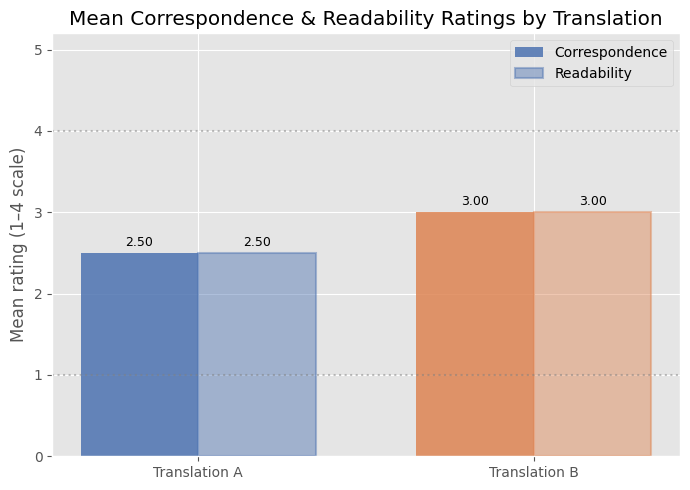

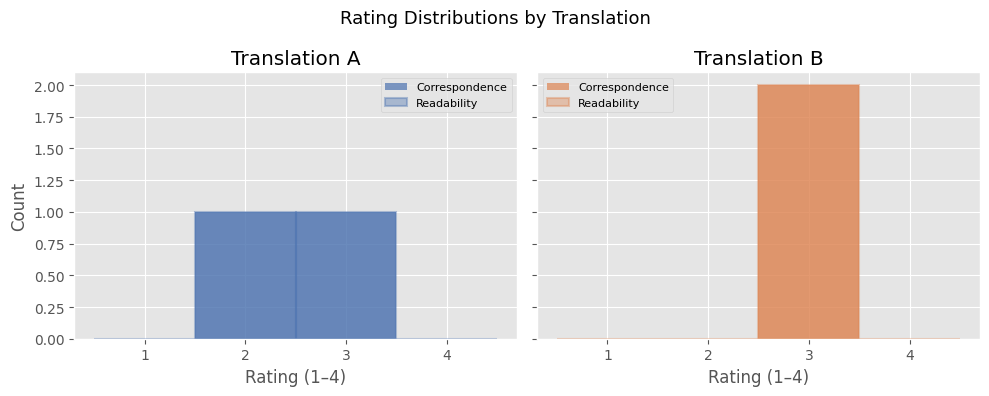

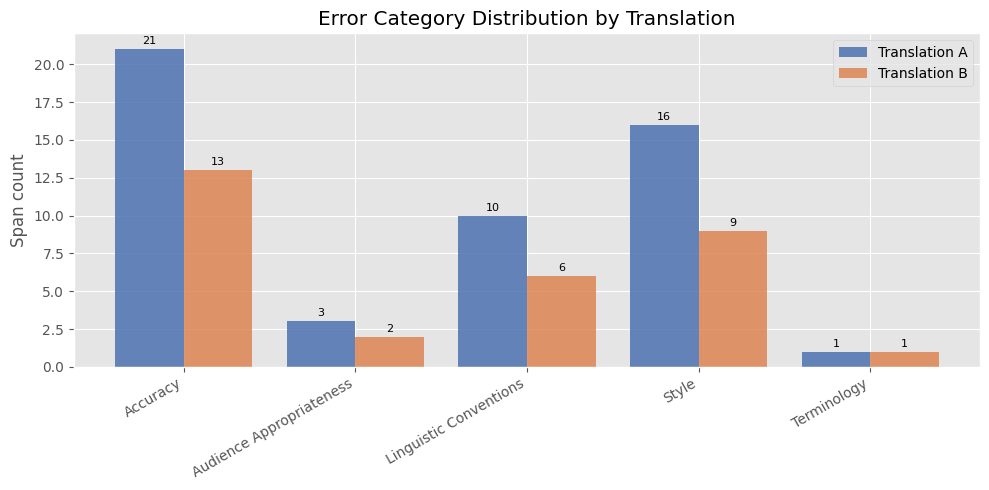

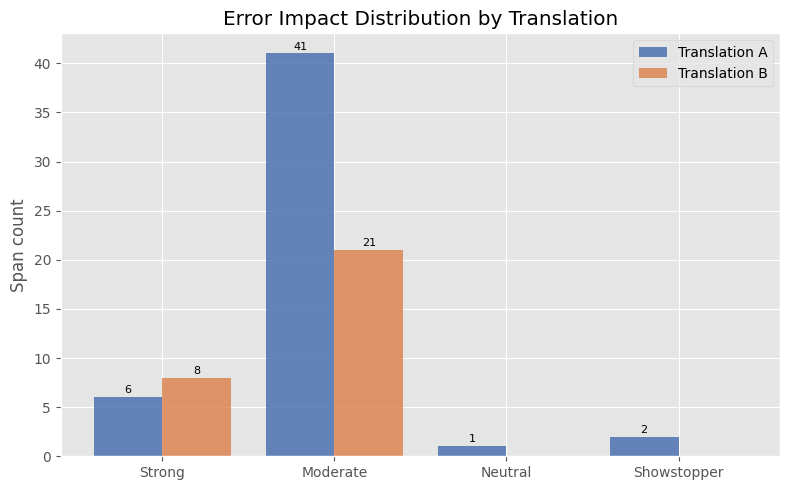

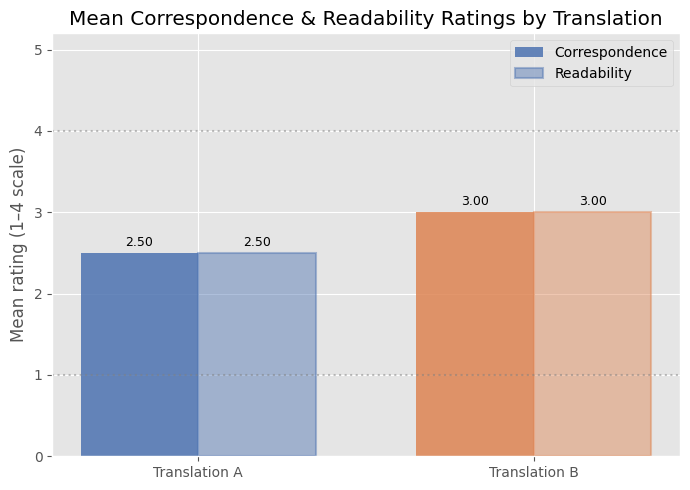

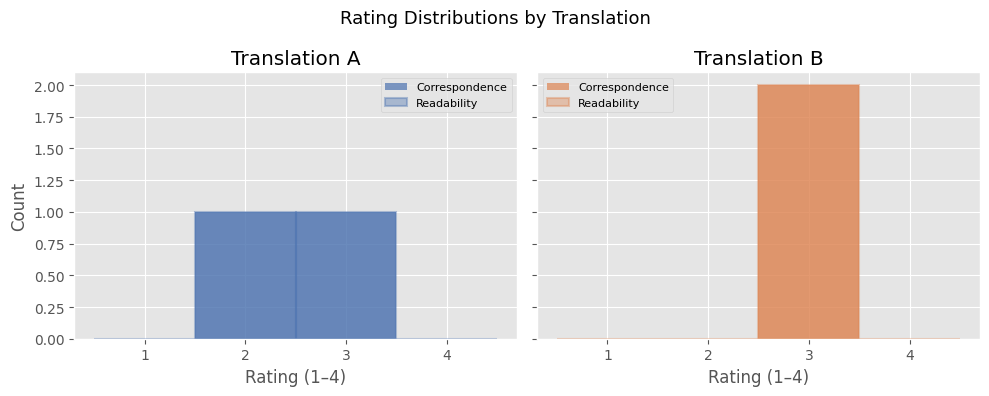

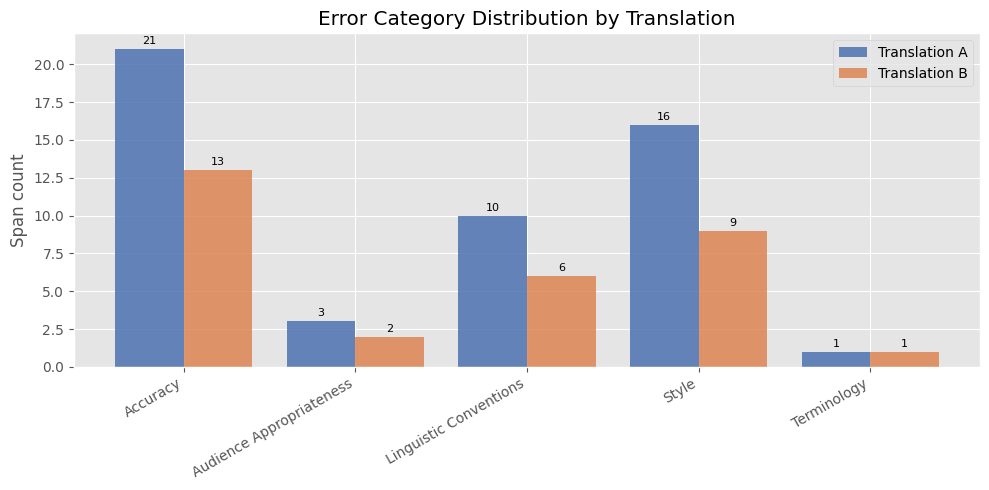

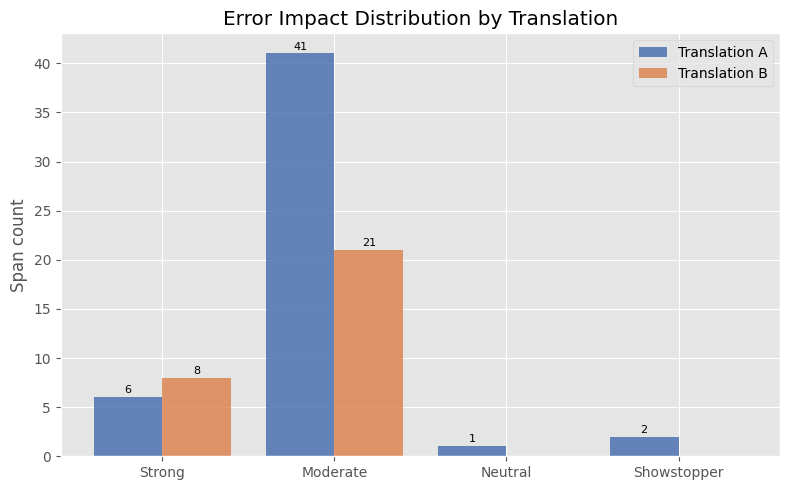

In [18]:
# Preview charts inline (optional — comment out if you only want the HTML report)
display(HTML("<h3>Ratings (mean)</h3>"))
display(chart_ratings_comparison(conditions))

display(HTML("<h3>Rating Distributions</h3>"))
display(chart_rating_distributions(conditions))

display(HTML("<h3>Error Categories</h3>"))
display(chart_error_categories(conditions))

display(HTML("<h3>Error Impact</h3>"))
display(chart_error_impact(conditions))

## 6. Export Report

Assembles a self-contained HTML report with all sections.
The report is written to `OUTPUT_DIR`.

In [19]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

safe_name   = PROJECT_NAME.lower().replace(" ", "_")
base_path = os.path.join(OUTPUT_DIR, f"{safe_name}_comparison_{REPORT_DATE}.html")
report_path = base_path
counter = 1
while os.path.exists(report_path):
    report_path = os.path.join(OUTPUT_DIR, f"{safe_name}_comparison_{REPORT_DATE}({counter}).html")
    counter += 1

# ── HTML helpers ──────────────────────────────────────────────────────────────

def section(title, body_html, description=""):
    desc = f'<p class="section-desc">{description}</p>' if description else ""
    return f"""
<section>
  <h2>{title}</h2>
  {desc}
  <div class="section-body">{body_html}</div>
</section>
"""

def table(headers, rows, highlight_col=None):
    """Build an HTML table. highlight_col (0-indexed) gets bold text."""
    ths  = "".join(f"<th>{h}</th>" for h in headers)
    tbody = ""
    for row in rows:
        tds = ""
        for i, cell in enumerate(row):
            style = " style='font-weight:bold'" if i == highlight_col else ""
            tds += f"<td{style}>{cell}</td>"
        tbody += f"<tr>{tds}</tr>"
    return f"<div class='table-wrap'><table><thead><tr>{ths}</tr></thead><tbody>{tbody}</tbody></table></div>"


# ── Section 1: Executive Summary ──────────────────────────────────────────────

def fmt_mean(vals):
    return f"{np.mean(vals):.2f}" if vals else "—"

def fmt_f1(v):
    return f"{v:.3f}" if v is not None else "—"

def fmt_kappa(v):
    if v is None:
        return "—"
    return f"{v:.3f} ({kappa_label(v)})"

summary_headers = [
    "Translation", "Annotators", "Total Spans",
    "Mean Correspondence", "Mean Readability",
    "Span F1", "Mean Cohen's κ"
]
summary_rows = [
    [
        c["label"],
        c["n_annotators"],
        c["total_spans"],
        fmt_mean(c["corr_ratings"]),
        fmt_mean(c["read_ratings"]),
        fmt_f1(c["avg_f1"]),
        fmt_kappa(c["mean_kappa"]),
    ]
    for c in conditions
]

exec_summary_html = table(summary_headers, summary_rows, highlight_col=0)

# Add a brief winner-per-metric note
def winner(key, higher_is_better=True):
    vals = [(c["label"], c[key]) for c in conditions if c[key] is not None]
    if not vals:
        return "N/A"
    vals = [(c["label"], np.mean(c[key])) if isinstance(c[key], list) else (c["label"], c[key])
            for c in conditions]
    best = max(vals, key=lambda x: x[1]) if higher_is_better else min(vals, key=lambda x: x[1])
    return best[0]

winner_rows = [
    ["Mean correspondence (higher = better)", winner("corr_ratings")],
    ["Mean readability (higher = better)",    winner("read_ratings")],
    ["Total spans flagged (fewer = better)",  winner("total_spans", higher_is_better=False)],
    ["Span F1 — annotator reliability (higher = more trustworthy data)", winner("avg_f1")],
    ["Cohen's κ — annotator reliability (higher = more trustworthy data)", winner("mean_kappa")],
]
winner_table_html = table(["Metric", "Favors"], winner_rows)

exec_html = exec_summary_html + "<h3 style='margin-top:1.5rem'>Metric Summary</h3>" + winner_table_html

exec_section = section(
    "Executive Summary",
    exec_html,
    description=(
        "Key metrics for each translation condition. "
        "Span F1 and Cohen's κ reflect annotator agreement, "
        "indicating how much the evaluation data can be trusted for that condition."
        "Cohen's κ measures category label agreement between annotators, "
        "but only on overlapping spans where they already agreed there was an error "
        "(the spans identified by Span F1)."
    )
)

print("Executive summary built.")

Executive summary built.


In [20]:
# ── Section 2: Correspondence & Readability Ratings ───────────────────────────

rating_headers = ["Translation", "N ratings", "Mean", "Median", "Min", "Max", "Distribution"]

def rating_detail_rows(key):
    from collections import Counter
    rows = []
    for c in conditions:
        vals = c[key]
        if not vals:
            rows.append([c["label"], 0, "—", "—", "—", "—", "—"])
            continue
        dist = Counter(vals)
        dist_str = " | ".join(f"{k}:{v}" for k, v in sorted(dist.items()))
        rows.append([
            c["label"],
            len(vals),
            f"{np.mean(vals):.2f}",
            f"{np.median(vals):.1f}",
            int(min(vals)),
            int(max(vals)),
            dist_str,
        ])
    return rows

# Combined summary table
combined_headers = ["Translation", "Mean Correspondence", "Mean Readability"]
combined_rows = [
    [
        c["label"],
        fmt_mean(c["corr_ratings"]),
        fmt_mean(c["read_ratings"]),
    ]
    for c in conditions
]
combined_table = "<h3>Combined</h3>" + table(combined_headers, combined_rows, highlight_col=0)

corr_table = "<h3>Correspondence</h3>" + table(rating_headers, rating_detail_rows("corr_ratings"), highlight_col=0)
read_table = "<h3>Readability</h3>"    + table(rating_headers, rating_detail_rows("read_ratings"), highlight_col=0)

ratings_html = combined_table + corr_table + read_table

ratings_section = section(
    "Correspondence &amp; Readability Ratings",
    ratings_html,
    description="Holistic evaluator ratings on a 1–4 scale. Correspondence measures accuracy relative to the source; readability measures fluency and naturalness in the target language."
)

print("Ratings section built.")

Ratings section built.


Error distribution section built.


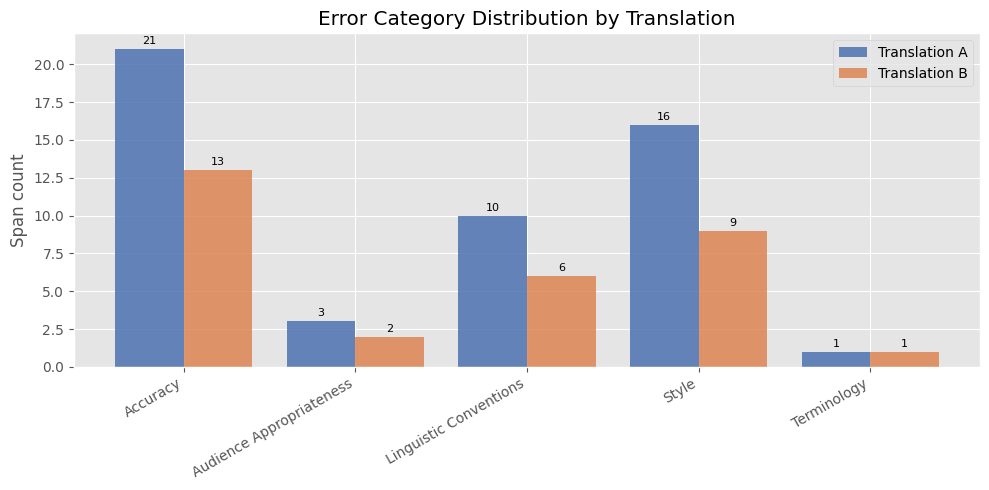

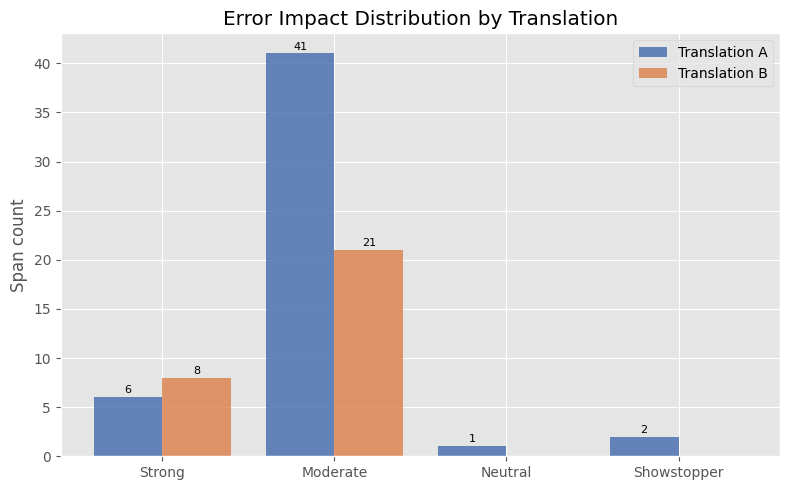

In [ ]:
# ── Section 3: Error Volume & Distribution ────────────────────────────────────

# Per-annotator, per-document span count table
span_headers = ["Translation", "Document ID", "Annotator ID", "Spans Marked"]
span_rows = []
for c in conditions:
    for doc_id, anns in sorted(c["data"].items()):
        for a in anns:
            span_rows.append([
                c["label"],
                doc_id,
                a["annotator_id"],
                len(a.get("enriched_labels", [])),
            ])
span_counts_table = table(span_headers, span_rows, highlight_col=0)

fig_cats   = chart_error_categories(conditions)
fig_impact = chart_error_impact(conditions)

# Error category table
all_cats = sorted(set(cat for c in conditions for cat in c["cat_counts"].keys()))
err_headers = ["Translation", "Total Spans"] + all_cats
err_rows    = [
    [c["label"], c["total_spans"]] + [c["cat_counts"].get(cat, 0) for cat in all_cats]
    for c in conditions
]
err_table_html = table(err_headers, err_rows, highlight_col=0)

# Impact table
all_impacts  = ["Strong", "Moderate", "Neutral"] + sorted(
    set(imp for c in conditions for imp in c["imp_counts"].keys())
    - {"Strong", "Moderate", "Neutral"}
)
imp_headers = ["Translation"] + all_impacts
imp_rows    = [
    [c["label"]] + [c["imp_counts"].get(imp, 0) for imp in all_impacts]
    for c in conditions
]
imp_table_html = table(imp_headers, imp_rows, highlight_col=0)

# Timing table
timing_headers = ["Translation", "Mean Lead Time (min)", "Min Lead Time (min)", "Max Lead Time (min)", "Total Lead Time (min)"]
timing_rows = []
for c in conditions:
    times = [
        a["lead_time_minutes"]
        for anns in c["data"].values()
        for a in anns
        if a.get("lead_time_minutes") is not None
    ]
    if times:
        timing_rows.append([
            c["label"],
            f"{np.mean(times):.1f}",
            f"{min(times):.1f}",
            f"{max(times):.1f}",
            f"{sum(times):.1f}",
        ])
    else:
        timing_rows.append([c["label"], "—", "—", "—", "—"])
timing_table_html = table(timing_headers, timing_rows, highlight_col=0)

errors_html = (
    "<p><em>Number of error spans marked by each evaluator per document.</em></p>"
    + span_counts_table
    + "<p><em>Total error spans flagged per translation, broken down by MQM error category. Higher counts indicate more identified errors of that type.</em></p>"
    + err_table_html
    + "<p><em>Error spans broken down by impact level. Strong errors have the greatest effect on translation quality.</em></p>"
    + imp_table_html
    + "<p><em>Lead time is active working time recorded by Label Studio.</em></p>"
    + timing_table_html
)

errors_section = section(
    "Error Volume &amp; Distribution",
    errors_html,
    description="Total error spans flagged by evaluators, broken down by MQM error category and impact level. Higher span counts indicate more identified errors in that translation."
)

print("Error distribution section built.")

In [22]:
# ── Section 4: Annotator Reliability (condensed) ─────────────────────────────

rel_headers = [
    "Translation", "Span F1", "F1 target (≥0.60)",
    "Mean Cohen's κ", "κ interpretation", "κ target (≥0.60)"
]

def target_badge(val, threshold):
    if val is None:
        return "—"
    return "✓" if val >= threshold else "✗"

rel_rows = [
    [
        c["label"],
        fmt_f1(c["avg_f1"]),
        target_badge(c["avg_f1"], 0.60),
        f"{c['mean_kappa']:.3f}" if c["mean_kappa"] is not None else "—",
        kappa_label(c["mean_kappa"]),
        target_badge(c["mean_kappa"], 0.60),
    ]
    for c in conditions
]

reliability_html = table(rel_headers, rel_rows, highlight_col=0)

reliability_section = section(
    "Annotator Reliability",
    reliability_html,
    description=(
        "Span F1 measures partial overlap agreement between annotator span boundaries. "
        "Cohen's κ measures agreement on error category labels for overlapping spans. "
        "Production deployment target for both metrics: ≥0.60. "
        "Low reliability in one condition means its quality metrics should be interpreted with caution."
    )
)

print("Reliability section built.")

Reliability section built.


In [23]:
# ── Section 5: Qualitative Comments ───────────────────────────────────────────

def comments_html_for_condition(c):
    comments = c["qual_comments"]
    if not comments:
        return "<p><em>No free-text comments recorded for this translation.</em></p>"

    html = ""
    for entry in comments:
        aid = entry["annotator_id"]
        html += f"<div class='comment-block'><strong>Annotator {aid}</strong>"
        for field, label in [
            ("document_issues",         "Document issues"),
            ("correspondence_comments", "Correspondence"),
            ("readability_comments",    "Readability"),
        ]:
            val = entry.get(field)
            if val and str(val).strip():
                escaped = str(val).replace("<", "&lt;").replace(">", "&gt;")
                html += f"<p><em>{label}:</em> {escaped}</p>"
        html += "</div>"
    return html

qual_inner = ""
for c in conditions:
    qual_inner += f"<h3>{c['label']}</h3>" + comments_html_for_condition(c)

qual_section = section(
    "Qualitative Evaluator Comments",
    qual_inner,
    description="Free-text comments entered by evaluators for document issues, correspondence, and readability. All comments are included as submitted."
)

print("Qualitative section built.")

Qualitative section built.


In [24]:
# ── Assemble and write HTML ────────────────────────────────────────────────────

condition_labels = " vs. ".join(c["label"] for c in conditions)
total_annotations = sum(sum(len(v) for v in c["data"].values()) for c in conditions)

html_doc = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>{PROJECT_NAME} – Translation Quality Comparison – {REPORT_DATE}</title>
  <style>
    body        {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
                   max-width: 1100px; margin: 2rem auto; padding: 0 1.5rem;
                   color: #222; line-height: 1.55; }}
    h1          {{ border-bottom: 3px solid #444; padding-bottom: .5rem; }}
    h2          {{ color: #333; margin-top: .5rem; margin-bottom: .5rem; }}
    h3          {{ color: #555; }}
    .meta       {{ color: #666; font-size: .9rem; margin-bottom: 2rem; }}
    .section-desc {{ color: #555; font-style: italic; font-size: .92rem;
                     margin: .4rem 0 1rem 0; }}
    section     {{ background: #fafafa; border: 1px solid #e0e0e0;
                   border-radius: 6px; padding: 1.2rem 1.5rem;
                   margin-bottom: 2rem; }}
    .table-wrap {{ overflow-x: auto; margin-top: .5rem; }}
    table       {{ border-collapse: collapse; white-space: nowrap; width: 100%; }}
    th, td      {{ border: 1px solid #ddd; padding: .35rem .7rem; text-align: left; }}
    thead tr    {{ background: #f0f0f0; }}
    .comment-block {{ border-left: 3px solid #ccc; padding: .5rem 1rem;
                      margin: .75rem 0; background: #fff; }}
    .comment-block p {{ margin: .3rem 0; }}
  </style>
</head>
<body>
  <h1>{PROJECT_NAME} – Translation Quality Comparison Report</h1>
  <p class="meta">
    Round date: {REPORT_DATE} &nbsp;|&nbsp;
    Conditions: {condition_labels} &nbsp;|&nbsp;
    Total annotations: {total_annotations}
  </p>
  {exec_section}
  {ratings_section}
  {errors_section}
  {reliability_section}
  {qual_section}
</body>
</html>"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(html_doc)

print(f"Report written to: {report_path}")
display(HTML(f'<b>Report saved:</b> <code>{report_path}</code>'))

Report written to: ./reports\tqe-2026-1-project6-compare_comparison_2026-06-10(1).html
